In [1]:
%%bash
apt-get install -y git-lfs > /dev/null 2>&1
git lfs install

git clone --no-checkout --depth 1 https://github.com/spMohanty/PlantVillage-Dataset.git /kaggle/working/PlantVillage-Dataset
cd /kaggle/working/PlantVillage-Dataset
git sparse-checkout init --cone
git sparse-checkout set raw/color
git checkout

Git LFS initialized.
Your branch is up to date with 'origin/master'.


Cloning into '/kaggle/working/PlantVillage-Dataset'...


In [2]:
!pip install pyyaml tqdm -q

## Create project structure

In [3]:
import os
for folder in [
    "/kaggle/working/src/common",
    "/kaggle/working/src/models/mobilenetv2",
    "/kaggle/working/checkpoints/mobilenetv2",
    "/kaggle/working/results",
]:
    os.makedirs(folder, exist_ok=True)

for folder in [
    "/kaggle/working/src",
    "/kaggle/working/src/common",
    "/kaggle/working/src/models",
    "/kaggle/working/src/models/mobilenetv2",
]:
    open(f"{folder}/__init__.py", "w").close()

## Dataset

In [4]:
%%writefile /kaggle/working/src/common/dataset.py
import random
from torch.utils.data import Dataset
import torch
from PIL import Image
import torchvision.transforms as transforms
from pathlib import Path

PLANTVILLAGE_DIR = Path("/kaggle/working/PlantVillage-Dataset/raw/color")

class PlantDiseaseDataset(Dataset):
    def __init__(self, samples, label2idx, transform=None):
        self.samples = samples
        self.label2idx = label2idx
        self.transform = transform
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        path, label_name = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform is not None:
            img = self.transform(img)
        label_idx = self.label2idx[label_name]
        return img, torch.tensor(label_idx, dtype=torch.long)


train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

Writing /kaggle/working/src/common/dataset.py


## Dataloader

In [5]:
%%writefile /kaggle/working/src/common/dataloader.py
import random
from pathlib import Path
from torch.utils.data import DataLoader
from src.common.dataset import (
    PlantDiseaseDataset, PLANTVILLAGE_DIR, train_transform, val_transform,
)

def list_files_by_class(root_dir, ext_patterns=("*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG", "*.PNG")):
    classes, samples = [], []
    if not root_dir.exists():
        print(f"Directory not found: {root_dir}. Treating as empty dataset.")
        return classes, samples
    for class_dir in sorted(root_dir.iterdir()):
        if not class_dir.is_dir():
            continue
        class_name = class_dir.name
        classes.append(class_name)
        file_list = []
        for ext in ext_patterns:
            file_list.extend(class_dir.rglob(ext))
        for p in sorted(file_list):
            samples.append((str(p), class_name))
    print(f"Found {len(classes)} classes and {len(samples)} samples in {root_dir}")
    return sorted(classes), samples

def split_samples(samples, train_frac=0.8, val_frac=0.1, test_frac=0.1, seed=42):
    assert abs(train_frac + val_frac + test_frac - 1.0) < 1e-6
    samples = samples[:]
    random.Random(seed).shuffle(samples)
    n = len(samples)
    n_train = int(train_frac * n)
    n_val   = int(val_frac * n)
    train = samples[:n_train]
    val   = samples[n_train:n_train + n_val]
    test  = samples[n_train + n_val:]
    print(f"Split {len(samples)} samples into {len(train)} train, {len(val)} val, {len(test)} test")
    return train, val, test

def create_dataloaders(batch_size=32, num_workers=2):
    pv_classes, pv_samples = list_files_by_class(PLANTVILLAGE_DIR)
    label2idx = {label: i for i, label in enumerate(pv_classes)}
    pv_train, pv_val, pv_test = split_samples(pv_samples)
    pv_train_ds = PlantDiseaseDataset(pv_train, label2idx, transform=train_transform)
    pv_val_ds   = PlantDiseaseDataset(pv_val,   label2idx, transform=val_transform)
    pv_test_ds  = PlantDiseaseDataset(pv_test,  label2idx, transform=val_transform)
    loaders = {
        "train": DataLoader(pv_train_ds, batch_size=batch_size, shuffle=True,  num_workers=num_workers),
        "val":   DataLoader(pv_val_ds,   batch_size=batch_size, shuffle=False, num_workers=num_workers),
        "test":  DataLoader(pv_test_ds,  batch_size=batch_size, shuffle=False, num_workers=num_workers),
    }
    return {"loaders": loaders, "label2idx": label2idx, "num_classes": len(pv_classes)}

Writing /kaggle/working/src/common/dataloader.py


## Model

In [6]:
%%writefile /kaggle/working/src/models/mobilenetv2/model.py

import torch
import torch.nn as nn
from torchvision.models import MobileNet_V2_Weights, mobilenet_v2


class MobileNetV2Classifier(nn.Module):
    def __init__(self, num_classes=38, pretrained=True, dropout=0.2):
        super().__init__()

        weights = MobileNet_V2_Weights.DEFAULT if pretrained else None
        self.model = mobilenet_v2(weights=weights)

        in_features = self.model.classifier[-1].in_features
        self.model.classifier = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(in_features, num_classes),
        )

    def forward(self, x):
        return self.model(x)


def create_mobilenetv2(num_classes=38, pretrained=True, dropout=0.2):
    return MobileNetV2Classifier(
        num_classes=num_classes,
        pretrained=pretrained,
        dropout=dropout,
    )

Writing /kaggle/working/src/models/mobilenetv2/model.py


## Hyperparameter Combos & Config

In [7]:
from pathlib import Path

# -------------------
# Fixed config
# -------------------
EPOCHS = 18
BATCH_SIZE = 32
NUM_WORKERS = 2
WEIGHT_DECAY = 1e-4
STEP_SIZE = 7
GAMMA = 0.1
PRETRAINED = True

# -------------------
# Hyperparameter combos: (LR, DROPOUT)
# -------------------
COMBOS = [
    (0.0001, 0.1)
]

RESULTS_DIR = Path("/kaggle/working/results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
CKPT_DIR = Path("/kaggle/working/checkpoints/mobilenetv2")
CKPT_DIR.mkdir(parents=True, exist_ok=True)

def combo_tag(lr, dropout):
    """e.g. lr0.001_drop0.2"""
    return f"lr{lr}_drop{dropout}"

print(f"Will run {len(COMBOS)} combos:")
for lr, do in COMBOS:
    print(f"  LR={lr}, DROPOUT={do}  ->  tag: {combo_tag(lr, do)}")

Will run 1 combos:
  LR=0.0001, DROPOUT=0.1  ->  tag: lr0.0001_drop0.1


## Load data once (shared across all combos)

In [8]:
import sys
sys.path.append("/kaggle/working")

import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
import csv

from src.models.mobilenetv2.model import create_mobilenetv2
from src.common.dataloader import create_dataloaders

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

data = create_dataloaders(batch_size=BATCH_SIZE, num_workers=NUM_WORKERS)
loaders     = data["loaders"]
num_classes = data["num_classes"]

train_loader = loaders["train"]
val_loader   = loaders["val"]
test_loader  = loaders["test"]

print(f"Number of classes: {num_classes}")

Using device: cuda
Found 38 classes and 54305 samples in /kaggle/working/PlantVillage-Dataset/raw/color
Split 54305 samples into 43444 train, 5430 val, 5431 test
Number of classes: 38


## Training & evaluation functions

In [9]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(loader, desc="Training", leave=False):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100.0 * correct / total
    return epoch_loss, epoch_acc


def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Validation", leave=False):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100.0 * correct / total
    return epoch_loss, epoch_acc


def test_model(model, test_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="Testing"):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / len(test_loader)
    epoch_acc = 100.0 * correct / total
    return epoch_loss, epoch_acc

## Run all combos

In [10]:
import time

all_summaries = []   # collect summary row per combo

for combo_idx, (LR, DROPOUT) in enumerate(COMBOS):
    tag = combo_tag(LR, DROPOUT)
    print("\n" + "=" * 70)
    print(f"COMBO {combo_idx + 1}/{len(COMBOS)}: LR={LR}, DROPOUT={DROPOUT}  [{tag}]")
    print("=" * 70)

    # Paths for this combo
    best_ckpt   = CKPT_DIR / f"best_model_{tag}.pth"
    last_ckpt   = CKPT_DIR / f"last_model_{tag}.pth"
    train_csv   = RESULTS_DIR / f"training_results_{tag}.csv"
    test_csv    = RESULTS_DIR / f"test_results_{tag}.csv"

    # Fresh model
    model = create_mobilenetv2(
        num_classes=num_classes,
        pretrained=PRETRAINED,
        dropout=DROPOUT,
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=STEP_SIZE, gamma=GAMMA)

    # Training loop
    best_val_acc = 0.0
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    start_time = time.time()

    for epoch in range(EPOCHS):
        print(f"\n  Epoch [{epoch + 1}/{EPOCHS}]")

        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc     = validate_one_epoch(model, val_loader, criterion, device)
        scheduler.step()

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
        print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")

        torch.save(model.state_dict(), last_ckpt)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), best_ckpt)
            print(f"  -> Saved best model ({best_val_acc:.2f}%)")

        # Save training CSV after every epoch
        with open(train_csv, "w", newline="") as f:
            writer = csv.writer(f)
            writer.writerow(["epoch", "train_loss", "train_acc", "val_loss", "val_acc"])
            for i in range(len(history["train_loss"])):
                writer.writerow([
                    i + 1,
                    f'{history["train_loss"][i]:.4f}',
                    f'{history["train_acc"][i]:.2f}',
                    f'{history["val_loss"][i]:.4f}',
                    f'{history["val_acc"][i]:.2f}',
                ])

    elapsed = time.time() - start_time
    print(f"\n  Training complete in {elapsed/60:.1f} min. Best val acc: {best_val_acc:.2f}%")
    print(f"  Saved training CSV -> {train_csv}")

    # Test evaluation
    model.load_state_dict(torch.load(best_ckpt, map_location=device))
    test_loss, test_acc = test_model(model, test_loader, criterion, device)
    print(f"  Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")

    with open(test_csv, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["test_loss", "test_acc"])
        writer.writerow([f"{test_loss:.4f}", f"{test_acc:.2f}"])
    print(f"  Saved test CSV -> {test_csv}")

    all_summaries.append({
        "lr": LR,
        "dropout": DROPOUT,
        "tag": tag,
        "best_val_acc": best_val_acc,
        "test_loss": test_loss,
        "test_acc": test_acc,
        "time_min": elapsed / 60,
        "history": history,
    })

    # Free GPU memory
    del model, optimizer, scheduler
    torch.cuda.empty_cache()

print("\n" + "=" * 70)
print("ALL COMBOS COMPLETE")
print("=" * 70)


COMBO 1/1: LR=0.0001, DROPOUT=0.1  [lr0.0001_drop0.1]
Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 95.6MB/s]



  Epoch [1/18]


  Train Loss: 0.4467 | Train Acc: 89.70%
  Val Loss:   0.0426 | Val Acc:   98.78%
  -> Saved best model (98.78%)

  Epoch [2/18]


  Train Loss: 0.0536 | Train Acc: 98.57%
  Val Loss:   0.0218 | Val Acc:   99.24%
  -> Saved best model (99.24%)

  Epoch [3/18]


...

  Train Loss: 0.0030 | Train Acc: 99.94%
  Val Loss:   0.0082 | Val Acc:   99.74%

  Epoch [17/18]


  Train Loss: 0.0025 | Train Acc: 99.97%
  Val Loss:   0.0077 | Val Acc:   99.83%

  Epoch [18/18]


  Train Loss: 0.0022 | Train Acc: 99.96%
  Val Loss:   0.0074 | Val Acc:   99.80%

  Training complete in 56.3 min. Best val acc: 99.85%
  Saved training CSV -> /kaggle/working/results/training_results_lr0.0001_drop0.1.csv


Testing: 100%|██████████| 170/170 [00:10<00:00, 16.44it/s]


  Test Loss: 0.0088 | Test Acc: 99.82%
  Saved test CSV -> /kaggle/working/results/test_results_lr0.0001_drop0.1.csv

ALL COMBOS COMPLETE


## Summary table

In [11]:
import csv

summary_csv = RESULTS_DIR / "summary_all_combos.csv"
with open(summary_csv, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["lr", "dropout", "best_val_acc", "test_loss", "test_acc", "time_min"])
    for s in all_summaries:
        writer.writerow([
            s["lr"], s["dropout"],
            f'{s["best_val_acc"]:.2f}',
            f'{s["test_loss"]:.4f}',
            f'{s["test_acc"]:.2f}',
            f'{s["time_min"]:.1f}',
        ])

print(f"Saved summary -> {summary_csv}\n")
header = f'{"LR":<10} {"Dropout":<10} {"Best Val Acc":<14} {"Test Acc":<12} {"Time (min)":<10}'
print(header)
print("-" * 56)
for s in all_summaries:
    row = f'{s["lr"]:<10} {s["dropout"]:<10} {s["best_val_acc"]:<14.2f} {s["test_acc"]:<12.2f} {s["time_min"]:<10.1f}'
    print(row)

Saved summary -> /kaggle/working/results/summary_all_combos.csv

LR         Dropout    Best Val Acc   Test Acc     Time (min)
--------------------------------------------------------
0.0001     0.1        99.85          99.82        56.3      


## Per-combo training curves

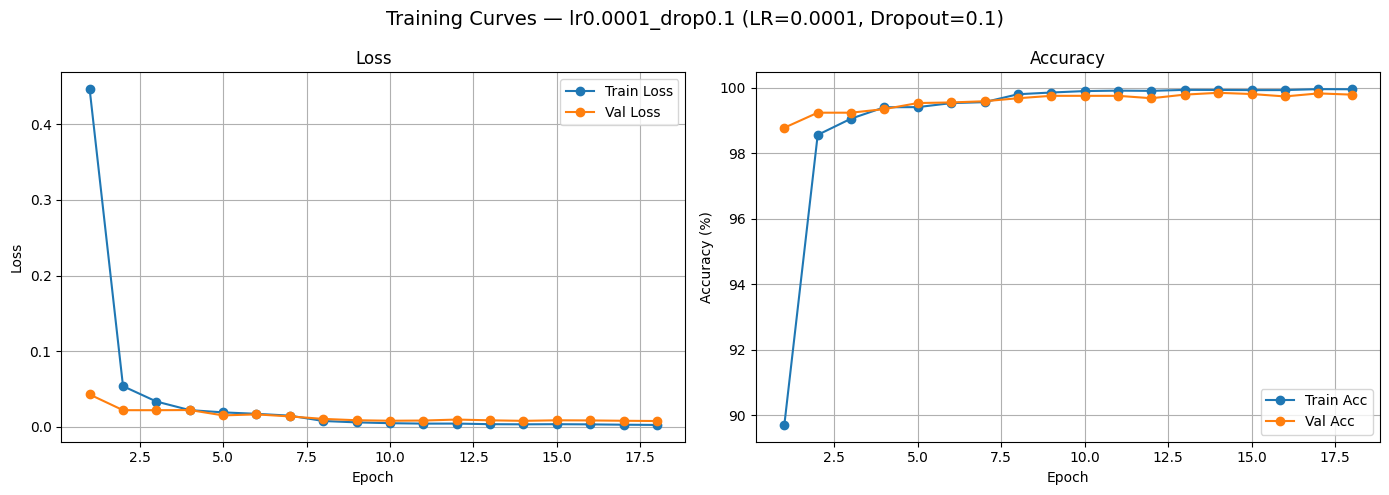

Saved -> /kaggle/working/results/training_curves_lr0.0001_drop0.1.png


In [12]:
import matplotlib.pyplot as plt

for s in all_summaries:
    tag = s["tag"]
    h = s["history"]
    ep = list(range(1, EPOCHS + 1))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    title = "Training Curves — " + tag + " (LR=" + str(s["lr"]) + ", Dropout=" + str(s["dropout"]) + ")"
    fig.suptitle(title, fontsize=14)

    ax1.plot(ep, h["train_loss"], "o-", label="Train Loss")
    ax1.plot(ep, h["val_loss"],   "o-", label="Val Loss")
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
    ax1.set_title("Loss"); ax1.legend(); ax1.grid(True)

    ax2.plot(ep, h["train_acc"], "o-", label="Train Acc")
    ax2.plot(ep, h["val_acc"],   "o-", label="Val Acc")
    ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy (%)")
    ax2.set_title("Accuracy"); ax2.legend(); ax2.grid(True)

    plt.tight_layout()
    fig_path = RESULTS_DIR / f"training_curves_{tag}.png"
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved -> {fig_path}")

## Comparison plots (all combos overlaid)

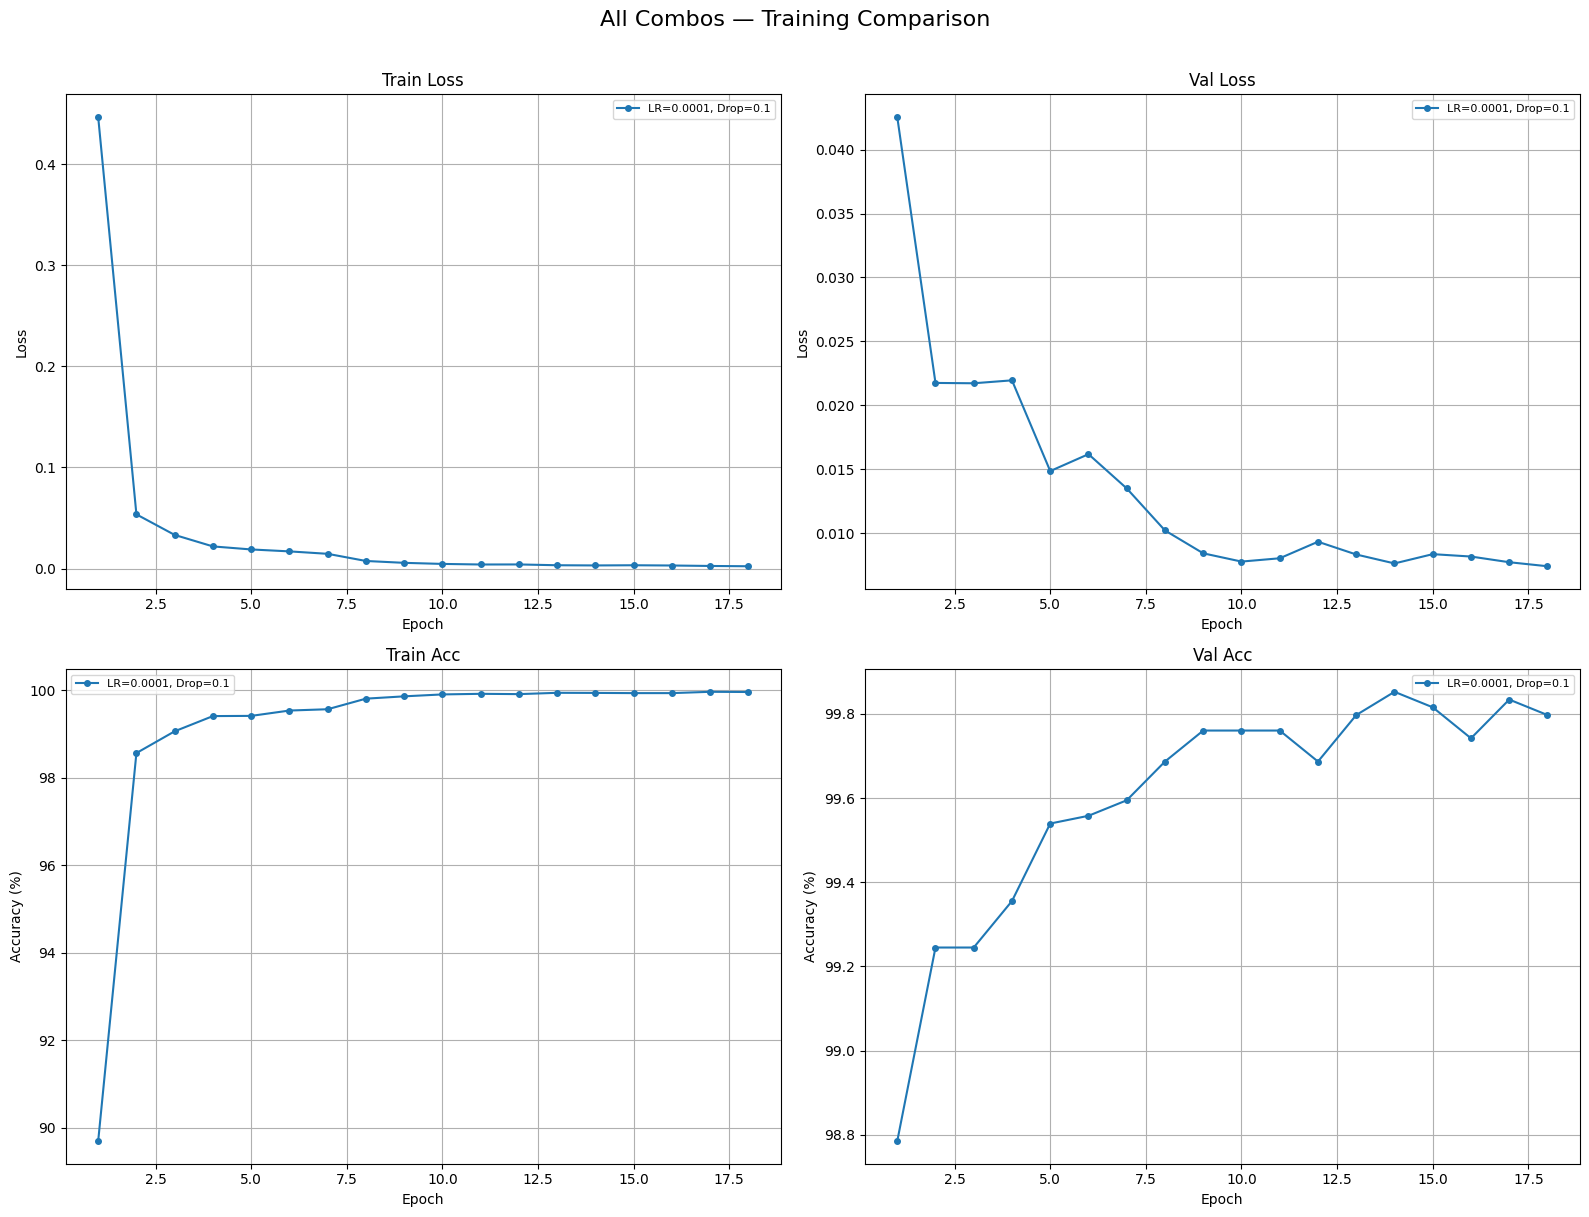

Saved -> /kaggle/working/results/comparison_all_combos.png


In [13]:
import matplotlib.pyplot as plt

ep = list(range(1, EPOCHS + 1))

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("All Combos — Training Comparison", fontsize=16, y=1.01)

titles = ["Train Loss", "Val Loss", "Train Acc", "Val Acc"]
keys   = ["train_loss", "val_loss", "train_acc", "val_acc"]
ylabels = ["Loss", "Loss", "Accuracy (%)", "Accuracy (%)"]

for ax, title, key, yl in zip(axes.flat, titles, keys, ylabels):
    for s in all_summaries:
        label = "LR=" + str(s["lr"]) + ", Drop=" + str(s["dropout"])
        ax.plot(ep, s["history"][key], "o-", markersize=4, label=label)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(yl)
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(True)

plt.tight_layout()
comp_path = RESULTS_DIR / "comparison_all_combos.png"
plt.savefig(comp_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved -> {comp_path}")

## List all saved files

In [14]:
import os

print("=== Results directory ===")
for f in sorted(os.listdir(RESULTS_DIR)):
    fpath = RESULTS_DIR / f
    size_kb = os.path.getsize(fpath) / 1024
    print(f"  {f}  ({size_kb:.1f} KB)")

print("")
print("=== Checkpoints ===")
for f in sorted(os.listdir(CKPT_DIR)):
    fpath = CKPT_DIR / f
    size_mb = os.path.getsize(fpath) / (1024 * 1024)
    print(f"  {f}  ({size_mb:.1f} MB)")

=== Results directory ===
  comparison_all_combos.png  (164.9 KB)
  summary_all_combos.csv  (0.1 KB)
  test_results_lr0.0001_drop0.1.csv  (0.0 KB)
  training_curves_lr0.0001_drop0.1.png  (86.7 KB)
  training_results_lr0.0001_drop0.1.csv  (0.6 KB)

=== Checkpoints ===
  best_model_lr0.0001_drop0.1.pth  (8.9 MB)
  last_model_lr0.0001_drop0.1.pth  (8.9 MB)


In [15]:
# =========================================================
# Per-combo test-set metrics: Accuracy, Precision, Recall, F1
# (macro + weighted + per-class report)
# =========================================================
import csv
import torch
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
)

# Get class names in the same order as label indices (label2idx: name -> idx)
label2idx = data["label2idx"]
class_names = [name for name, _ in sorted(label2idx.items(), key=lambda x: x[1])]


def evaluate_metrics(model, loader, device):
    """Run model on loader, return (y_true, y_pred) as numpy arrays."""
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Evaluating", leave=False):
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            all_preds.append(predicted.cpu())
            all_labels.append(labels.cpu())
    y_pred = torch.cat(all_preds).numpy()
    y_true = torch.cat(all_labels).numpy()
    return y_true, y_pred


metrics_summary_rows = []

for s in all_summaries:
    tag = s["tag"]
    LR, DROPOUT = s["lr"], s["dropout"]
    best_ckpt = CKPT_DIR / f"best_model_{tag}.pth"

    print("\n" + "=" * 70)
    print(f"Metrics for combo [{tag}]  (LR={LR}, Dropout={DROPOUT})")
    print("=" * 70)

    # Rebuild model and load best checkpoint
    model = create_mobilenetv2(
        num_classes=num_classes,
        pretrained=False,            # weights come from checkpoint
        dropout=DROPOUT,
    ).to(device)
    state = torch.load(best_ckpt, map_location=device)
    # handle both {"model_state_dict": ...} and raw state_dict
    if isinstance(state, dict) and "model_state_dict" in state:
        model.load_state_dict(state["model_state_dict"])
    else:
        model.load_state_dict(state)

    # Predictions on test set
    y_true, y_pred = evaluate_metrics(model, test_loader, device)

    # Overall metrics
    acc = accuracy_score(y_true, y_pred)
    prec_m, rec_m, f1_m, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    prec_w, rec_w, f1_w, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )

    print(f"Accuracy:           {acc*100:.2f}%")
    print(f"Precision (macro):  {prec_m*100:.2f}%   (weighted): {prec_w*100:.2f}%")
    print(f"Recall    (macro):  {rec_m*100:.2f}%   (weighted): {rec_w*100:.2f}%")
    print(f"F1-score  (macro):  {f1_m*100:.2f}%   (weighted): {f1_w*100:.2f}%")

    # Per-class report (precision / recall / f1 / support for each class)
    print("\nPer-class report:")
    report_str = classification_report(
        y_true, y_pred,
        labels=list(range(num_classes)),
        target_names=class_names,
        digits=4,
        zero_division=0,
    )
    print(report_str)

    # Save per-class CSV for this combo
    report_dict = classification_report(
        y_true, y_pred,
        labels=list(range(num_classes)),
        target_names=class_names,
        output_dict=True,
        zero_division=0,
    )
    per_class_csv = RESULTS_DIR / f"per_class_metrics_{tag}.csv"
    with open(per_class_csv, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["class", "precision", "recall", "f1_score", "support"])
        for cname in class_names:
            r = report_dict[cname]
            writer.writerow([
                cname,
                f'{r["precision"]:.4f}',
                f'{r["recall"]:.4f}',
                f'{r["f1-score"]:.4f}',
                int(r["support"]),
            ])
    print(f"Saved per-class metrics -> {per_class_csv}")

    metrics_summary_rows.append({
        "tag": tag, "lr": LR, "dropout": DROPOUT,
        "accuracy": acc,
        "precision_macro": prec_m, "recall_macro": rec_m, "f1_macro": f1_m,
        "precision_weighted": prec_w, "recall_weighted": rec_w, "f1_weighted": f1_w,
    })

# Save combined metrics summary across all combos
metrics_csv = RESULTS_DIR / "test_metrics_summary.csv"
with open(metrics_csv, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow([
        "lr", "dropout", "accuracy",
        "precision_macro", "recall_macro", "f1_macro",
        "precision_weighted", "recall_weighted", "f1_weighted",
    ])
    for r in metrics_summary_rows:
        writer.writerow([
            r["lr"], r["dropout"],
            f'{r["accuracy"]:.4f}',
            f'{r["precision_macro"]:.4f}', f'{r["recall_macro"]:.4f}', f'{r["f1_macro"]:.4f}',
            f'{r["precision_weighted"]:.4f}', f'{r["recall_weighted"]:.4f}', f'{r["f1_weighted"]:.4f}',
        ])
print(f"\nSaved overall metrics summary -> {metrics_csv}")


Metrics for combo [lr0.0001_drop0.1]  (LR=0.0001, Dropout=0.1)


Accuracy:           99.82%
Precision (macro):  99.78%   (weighted): 99.82%
Recall    (macro):  99.69%   (weighted): 99.82%
F1-score  (macro):  99.73%   (weighted): 99.82%

Per-class report:
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab     1.0000    1.0000    1.0000        57
                                 Apple___Black_rot     1.0000    1.0000    1.0000        45
                          Apple___Cedar_apple_rust     1.0000    1.0000    1.0000        23
                                   Apple___healthy     1.0000    1.0000    1.0000       154
                               Blueberry___healthy     1.0000    1.0000    1.0000       155
          Cherry_(including_sour)___Powdery_mildew     1.0000    1.0000    1.0000       116
                 Cherry_(including_sour)___healthy     1.0000    1.0000    1.0000        93
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot     0.9818    0.9310  

## Build inference bundle

Collect everything needed to classify a new image into one folder: the trained checkpoint, the class-label mapping, and a README. After the notebook finishes, download the whole `inference_bundle/` folder from Kaggle's output.

In [16]:
import json
import shutil
from pathlib import Path

# The single combo we trained: LR=0.0001, Dropout=0.1
BUNDLE_LR = 0.0001
BUNDLE_DROPOUT = 0.1
BUNDLE_TAG = combo_tag(BUNDLE_LR, BUNDLE_DROPOUT)

BUNDLE_DIR = Path("/kaggle/working/inference_bundle")
BUNDLE_DIR.mkdir(parents=True, exist_ok=True)

# 1) Copy the best checkpoint as best_model.pth
src_ckpt = CKPT_DIR / f"best_model_{BUNDLE_TAG}.pth"
dst_ckpt = BUNDLE_DIR / "best_model.pth"
shutil.copy2(src_ckpt, dst_ckpt)
print(f"Copied {src_ckpt.name} -> {dst_ckpt}")

# 2) Write class_labels.json (index -> class name)
idx2label = {idx: name for name, idx in label2idx.items()}
labels_ordered = [idx2label[i] for i in range(len(idx2label))]

labels_payload = {
    "num_classes": len(labels_ordered),
    "idx_to_label": labels_ordered,   # list: position = class index
    "label_to_idx": label2idx,        # dict: name -> index
}
labels_path = BUNDLE_DIR / "class_labels.json"
with open(labels_path, "w") as f:
    json.dump(labels_payload, f, indent=2)
print(f"Wrote {labels_path}  ({len(labels_ordered)} classes)")

# 3) Write README.md
num_classes_val = len(labels_ordered)

README_TEMPLATE = r"""# Plant Disease Classifier - Inference Bundle

Trained on the PlantVillage dataset (color images) using MobileNetV2
with transfer learning.

## Files

- **best_model.pth** - PyTorch state_dict for the trained MobileNetV2 classifier.
  The final classifier head is:
  `nn.Sequential(nn.Dropout(p=__DROPOUT__), nn.Linear(1280, __NUM_CLASSES__))`.
  Load with `model.load_state_dict(torch.load("best_model.pth", map_location="cpu"))`.

- **class_labels.json** - Mapping between class indices and human-readable class names.
  - `idx_to_label`: list where `idx_to_label[i]` is the class name for output index `i`.
  - `label_to_idx`: dict mapping class name to index.
  - `num_classes`: __NUM_CLASSES__.

- **README.md** - This file.

## Model architecture

```python
from torchvision.models import mobilenet_v2
import torch.nn as nn

model = mobilenet_v2(weights=None)
in_features = model.classifier[-1].in_features   # 1280
model.classifier = nn.Sequential(
    nn.Dropout(p=__DROPOUT__),
    nn.Linear(in_features, __NUM_CLASSES__),
)
```

## Inference preprocessing

Input images MUST be preprocessed exactly like validation data during training:

```python
from torchvision import transforms

preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])
```

- Image size: **224 x 224**
- Color mode: **RGB**
- Normalization: **ImageNet mean/std** (above)

## Minimal inference example

```python
import json
import torch
import torch.nn as nn
from PIL import Image
from torchvision import transforms
from torchvision.models import mobilenet_v2

# --- Load labels ---
with open("class_labels.json") as f:
    labels = json.load(f)
idx_to_label = labels["idx_to_label"]
num_classes = labels["num_classes"]

# --- Build model and load weights ---
model = mobilenet_v2(weights=None)
model.classifier = nn.Sequential(
    nn.Dropout(p=__DROPOUT__),
    nn.Linear(model.classifier[-1].in_features, num_classes),
)
state = torch.load("best_model.pth", map_location="cpu")
model.load_state_dict(state)
model.eval()

# --- Preprocess ---
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

img = Image.open("your_leaf.jpg").convert("RGB")
x = preprocess(img).unsqueeze(0)  # shape: (1, 3, 224, 224)

# --- Predict ---
with torch.no_grad():
    logits = model(x)
    probs = torch.softmax(logits, dim=1)[0]
    top5 = torch.topk(probs, k=5)

for score, idx in zip(top5.values.tolist(), top5.indices.tolist()):
    print(f"{idx_to_label[idx]}: {score*100:.2f}%")
```

## Training config (for reference)

- Base model: MobileNetV2 (ImageNet-pretrained)
- Learning rate: __LR__
- Dropout: __DROPOUT__
- Optimizer: Adam, weight_decay=1e-4
- LR scheduler: StepLR (step_size=7, gamma=0.1)
- Epochs: __EPOCHS__
- Batch size: __BATCH_SIZE__
- Loss: CrossEntropyLoss
- Input: RGB, 224x224, ImageNet normalization
- Train / Val / Test split: 80 / 10 / 10 (seed=42)
"""

readme = (
    README_TEMPLATE
    .replace("__NUM_CLASSES__", str(num_classes_val))
    .replace("__DROPOUT__", str(BUNDLE_DROPOUT))
    .replace("__LR__", str(BUNDLE_LR))
    .replace("__EPOCHS__", str(EPOCHS))
    .replace("__BATCH_SIZE__", str(BATCH_SIZE))
)

readme_path = BUNDLE_DIR / "README.md"
with open(readme_path, "w") as f:
    f.write(readme)
print(f"Wrote {readme_path}")

# 4) List the bundle contents
print("\n=== inference_bundle/ contents ===")
for p in sorted(BUNDLE_DIR.iterdir()):
    size = p.stat().st_size
    if size >= 1024 * 1024:
        size_str = f"{size / (1024*1024):.1f} MB"
    else:
        size_str = f"{size / 1024:.1f} KB"
    print(f"  {p.name}  ({size_str})")

print("\nDownload the whole inference_bundle/ folder from the Kaggle Output panel.")
print("The file to load in your app is: best_model.pth")


Copied best_model_lr0.0001_drop0.1.pth -> /kaggle/working/inference_bundle/best_model.pth
Wrote /kaggle/working/inference_bundle/class_labels.json  (38 classes)
Wrote /kaggle/working/inference_bundle/README.md

=== inference_bundle/ contents ===
  README.md  (3.0 KB)
  best_model.pth  (8.9 MB)
  class_labels.json  (2.6 KB)

Download the whole inference_bundle/ folder from the Kaggle Output panel.
The file to load in your app is: best_model.pth
